# Model cartoon plot gallery

A compact tour of `plot_model_cartoon`'s renderings and uncertainty displays,
one option per section — the sibling of the
[posterior predictive plot gallery](ppc_gallery.ipynb). For the full plotting
API, see the [Plotting tutorial](plotting.ipynb).

For demonstration purposes we inject a pre-computed trace into the model, so
this notebook runs in seconds without sampling. In practice you would obtain
the trace from `model.sample()`.

Unlike `plot_predictive`, the cartoon **re-simulates** from the posterior with
`ssm-simulators` — each drawn histogram and each piece of model geometry come
from the same posterior draw, so the histogram bands and the boundary ribbons
display the *same* uncertainty twice. The figure uses a three-way color
encoding: **model structure is neutral** (black/gray), **predictions** use the
predicted color, **observed data** uses the observed color.

In [1]:
import warnings
from pathlib import Path

import arviz as az
import pandas as pd

import hssm
from hssm.plotting import plot_model_cartoon

%config InlineBackend.figure_format = 'retina'

# The demo trace ships without predictive groups, so each plot call
# re-samples the posterior predictive and numba prints its object-mode
# compile notice every time (harmless; tracked in lnccbrown/HSSM#1080).
warnings.filterwarnings("ignore", message="Numba will use object mode")

fixtures = Path("../../tests/fixtures")
cav_data = pd.read_csv(fixtures / "cavanagh_theta_test.csv", index_col=None)
model = hssm.HSSM(
    model="ddm",
    data=cav_data,
    include=[
        {
            "name": "v",
            "prior": {"Intercept": {"name": "Normal", "mu": 0.0, "sigma": 1.5}},
            "formula": "v ~ 1 + stim",
            "link": "identity",
        },
        {
            "name": "a",
            "prior": {"Intercept": {"name": "Normal", "mu": 1.5, "sigma": 0.5}},
            "formula": "a ~ 1 + (1|participant_id)",
            "link": "identity",
        },
    ],
    p_outlier=0.0,
)
model._inference_obj = az.from_netcdf(fixtures / "idata_cavanagh_cartoon.nc")

Model initialized successfully.


## The default: graded uncertainty bands

Graded **50% + 94% equal-tailed bands** on the RT histograms above and below
the bounds, **fan-chart ribbons** on the decision boundaries, a graded
**drift-quantile fan**, graded **non-decision-time spans** under the dashed
reference line, and a **starting-point whisker**. One legend entry per layer.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


Output()

Output()

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


Output()

Output()

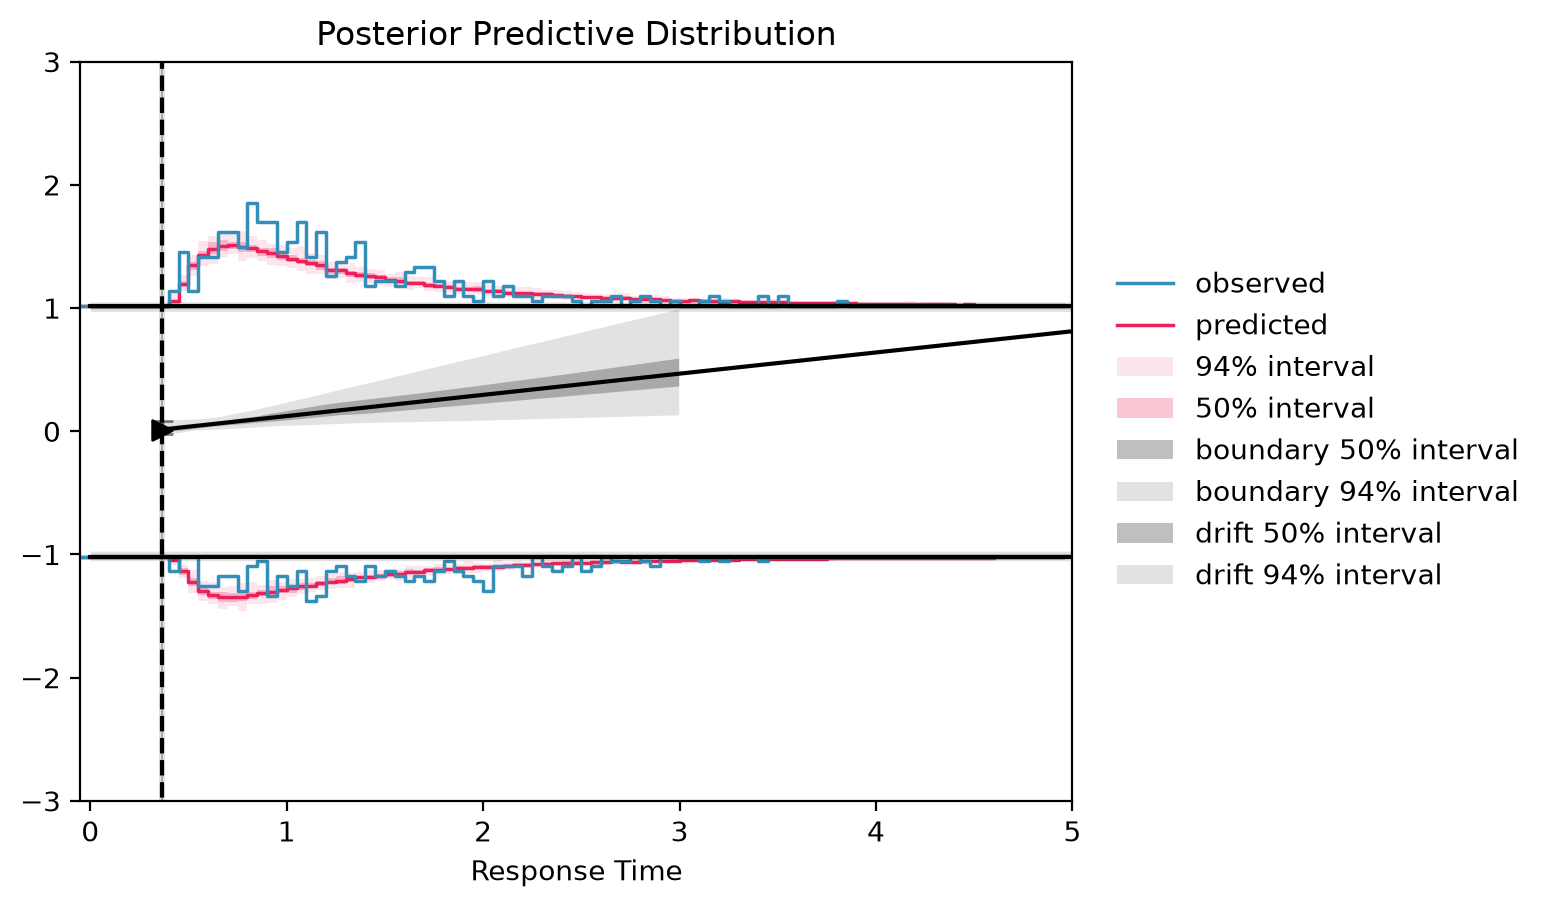

In [2]:
plot_model_cartoon(model, n_samples=20);

## `uncertainty="samples"` — the classic spaghetti, decluttered

Per-draw geometry and histogram curves at an **automatic opacity** that keeps
total ink roughly constant regardless of the number of draws. The old
per-draw vertical non-decision-time lines — the single worst clutter
contributor — are replaced by a rug of ticks at the bottom edge.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


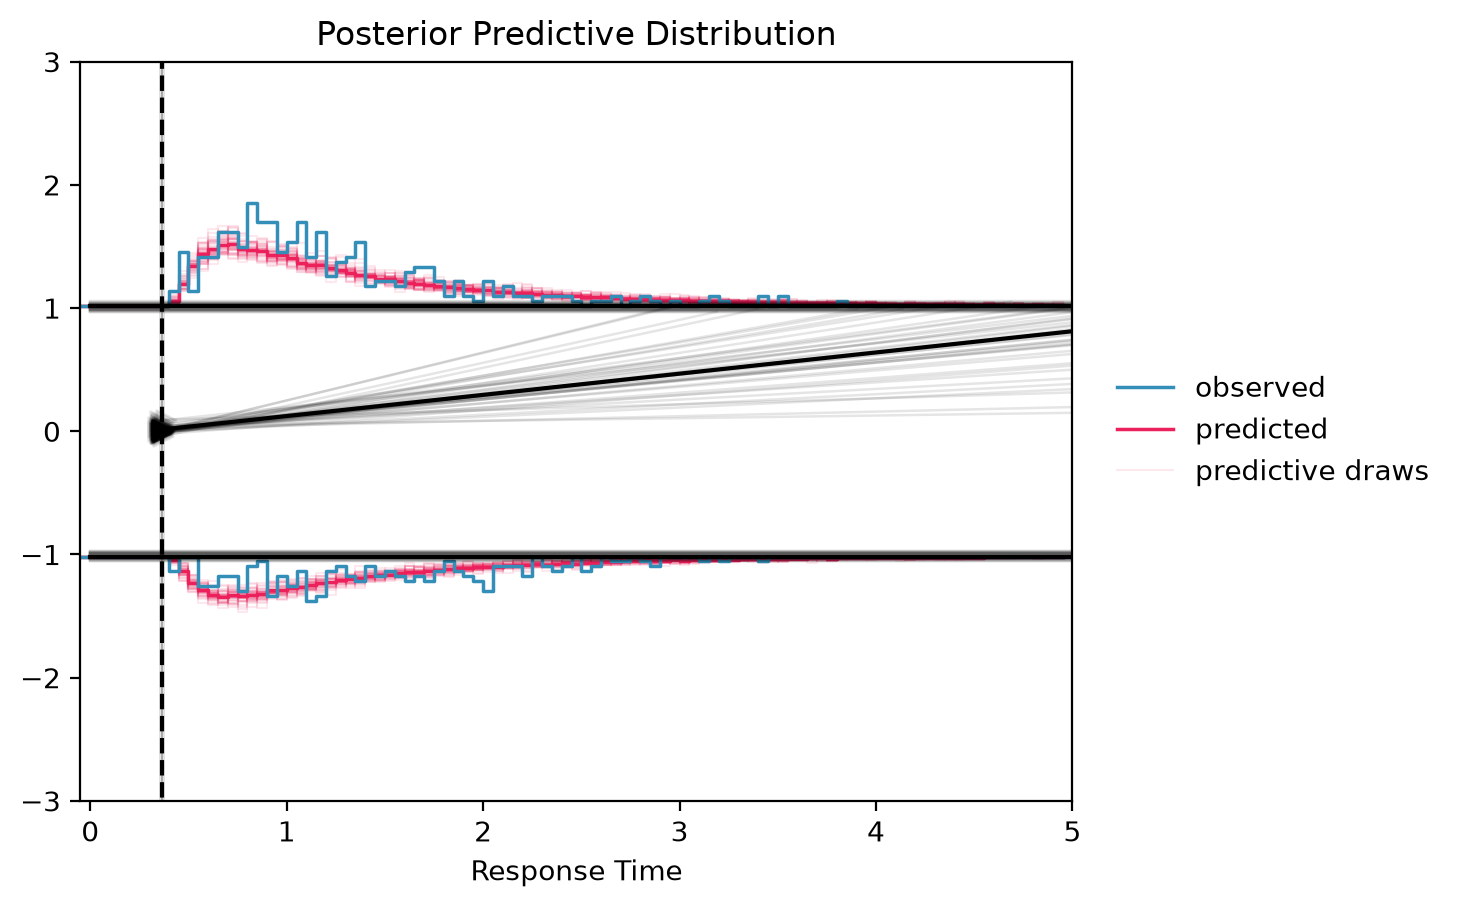

In [3]:
plot_model_cartoon(model, uncertainty="samples", n_samples=20);

## `uncertainty="both"`

Sample curves underneath the graded bands: honest about multimodality, while
the bands keep the summary readable.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


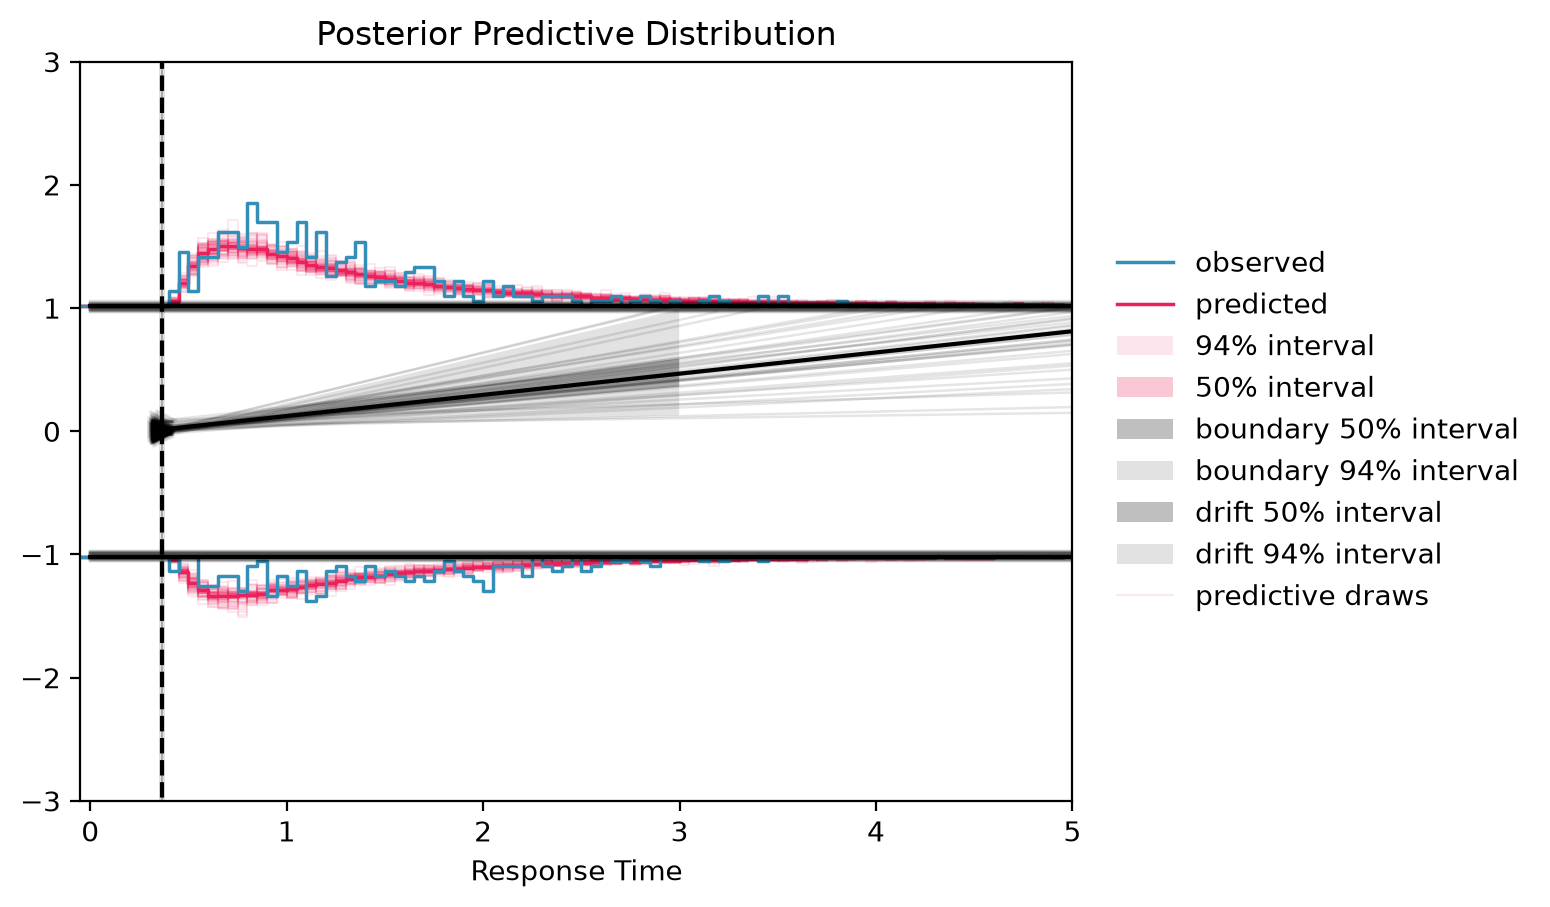

In [4]:
plot_model_cartoon(model, uncertainty="both", n_samples=20);

## Mean only — the previous default look

`uncertainty=None` reproduces the pre-redesign rendering: the plug-in
simulation at the posterior-mean parameters, no uncertainty layers.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


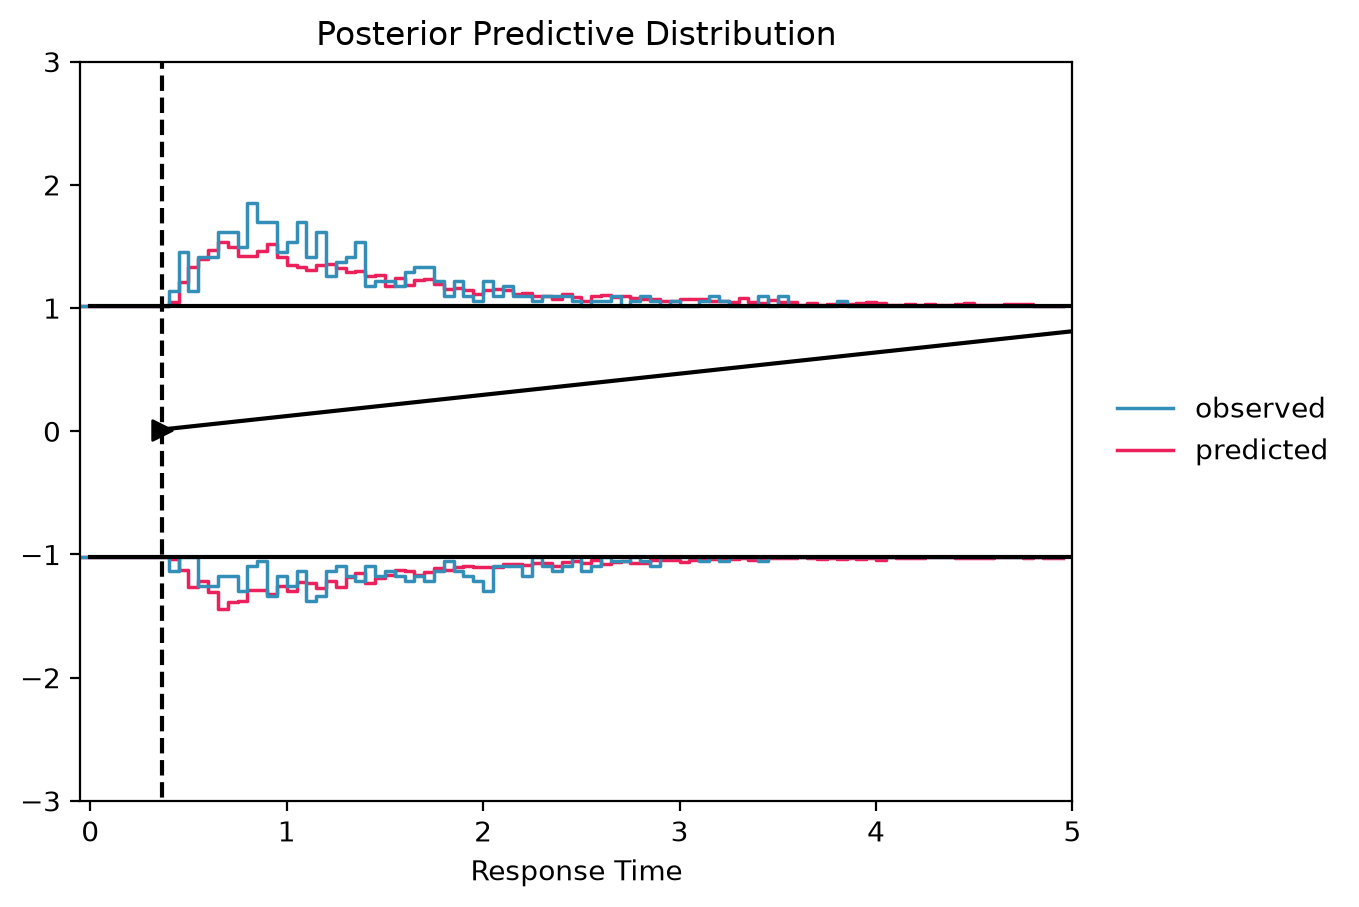

In [5]:
plot_model_cartoon(model, uncertainty=None);

## Custom graded bands

`hdi` accepts a list of interval specs for multiple graded bands (masses,
`"90%"` strings, or legacy quantile tuples).

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


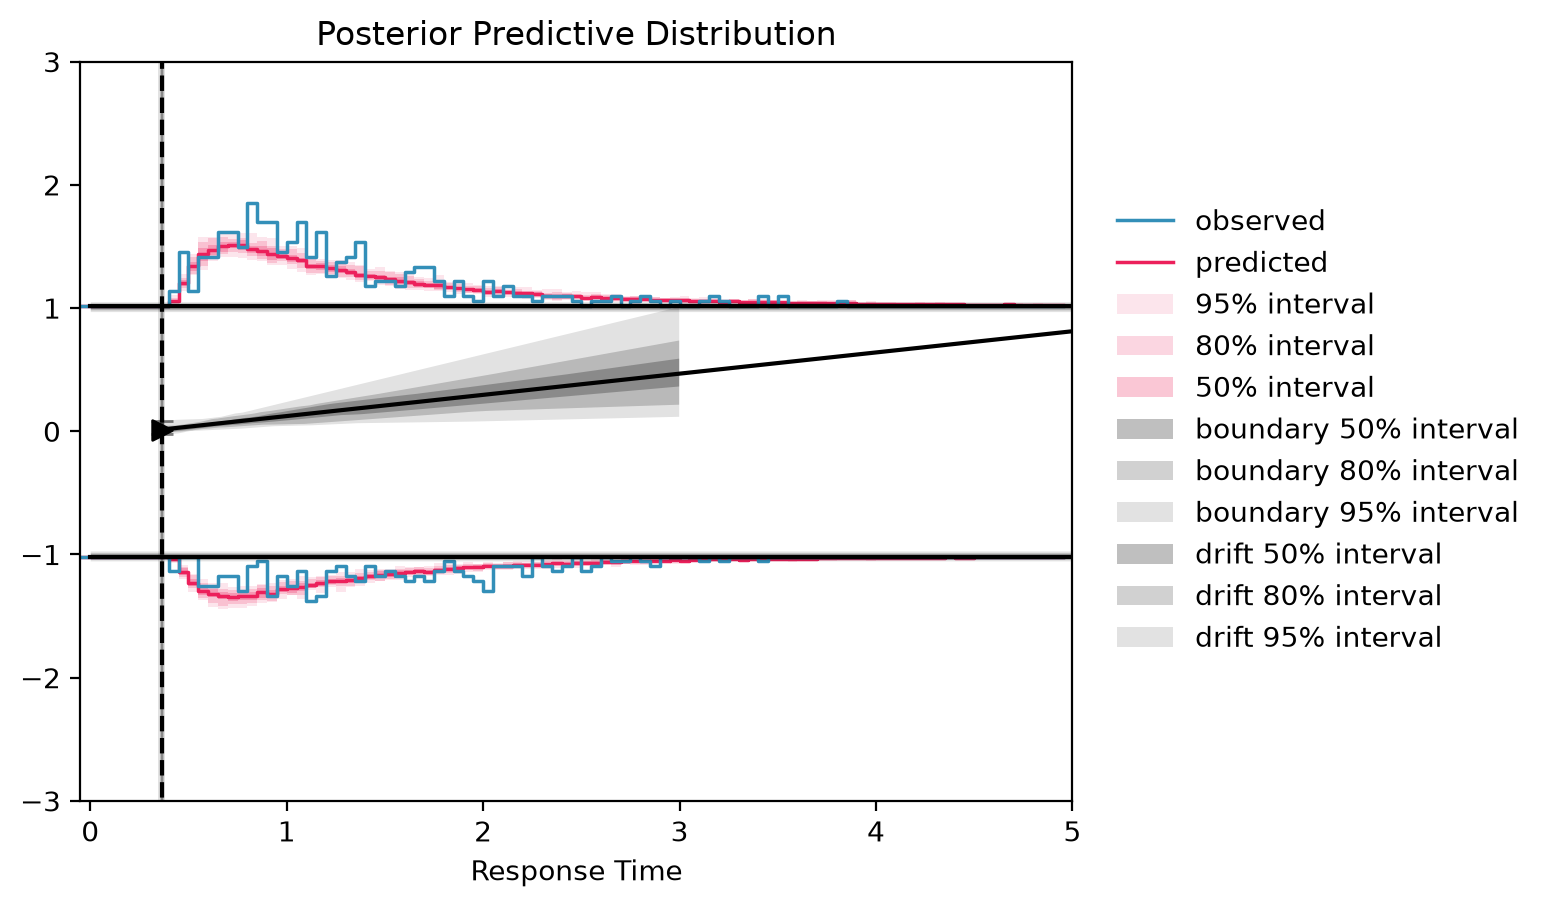

In [6]:
plot_model_cartoon(model, hdi=[0.5, 0.8, 0.95], n_samples=20);

## Controlling histogram height

Raw defective-density units can overrun the y-limits for very peaked RT
distributions. `hist_height` rescales all histogram curves by one common
factor so the tallest reaches exactly this height above its bound —
up/down and predicted/observed stay comparable.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


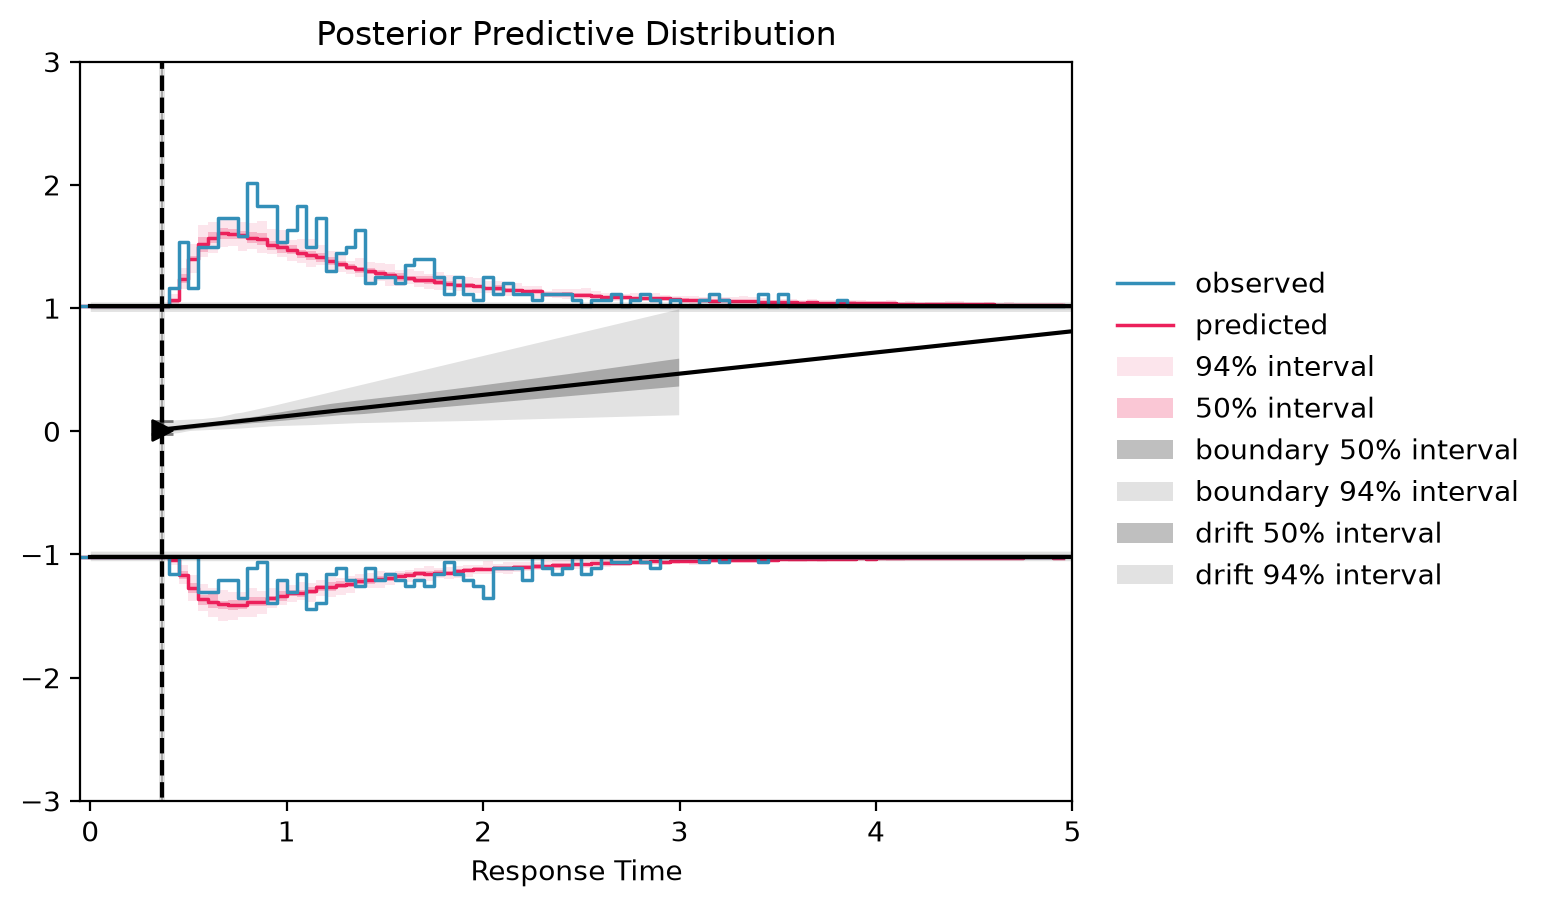

In [7]:
plot_model_cartoon(model, hist_height=1.0, n_samples=20);

## Styling

`colors`, `linestyles`, and `linewidths` follow the same
`[predicted, observed]` convention as `plot_predictive` (these parameters were
previously documented but silently ignored). The model geometry stays neutral
black by design; pass `color_model=` to change it.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


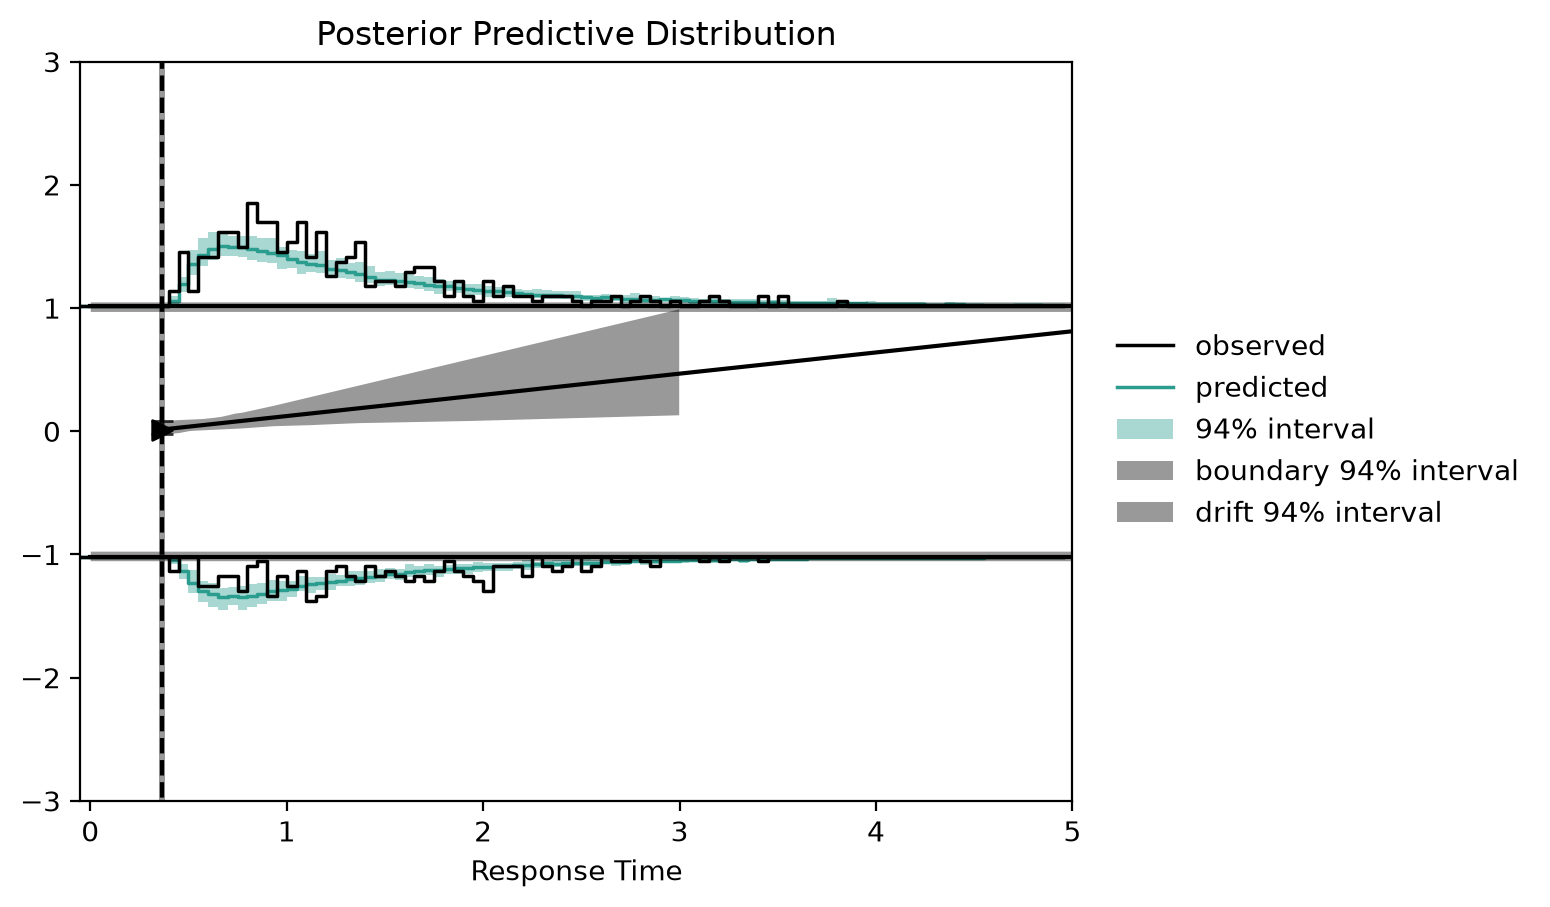

In [8]:
plot_model_cartoon(
    model,
    colors={"predicted": "#2a9d8f", "observed": "black"},
    alpha_uncertainty=0.4,
    hdi=[0.94],
    n_samples=20,
);

## Facets — the workhorse view

Everything composes with `row`/`col` faceting; one grid-level legend is
assembled from all facets.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


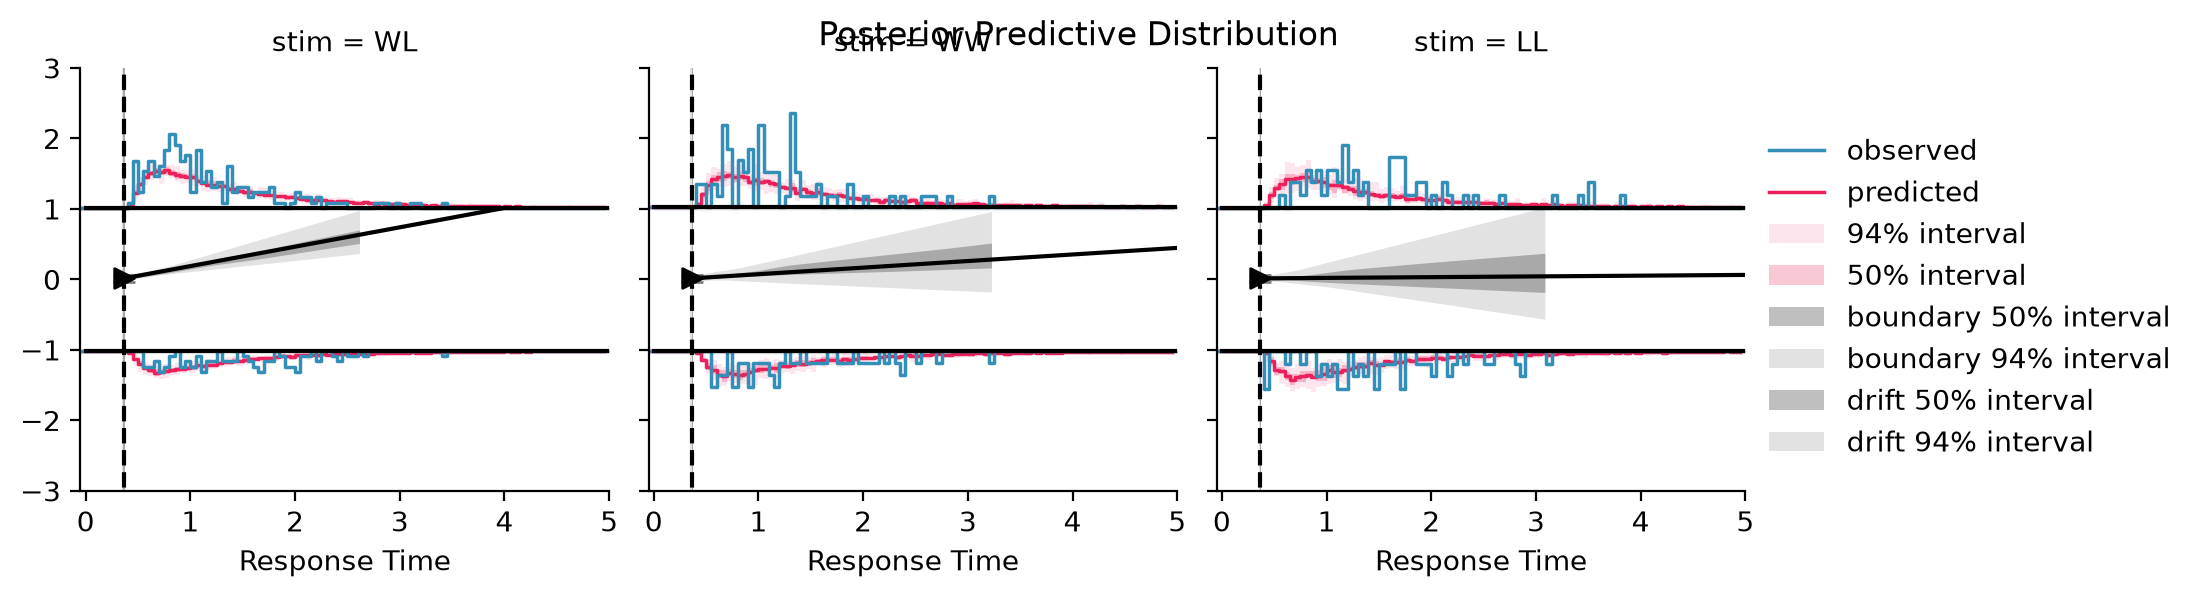

In [9]:
plot_model_cartoon(model, col="stim", n_samples=10);

## Reproducible figures with `random_state`

Everything random in the figure — which posterior draws are displayed,
every simulation, and the trajectories — flows from one seeded stream, so
the same `random_state` reproduces the figure exactly. Rendering the same
seed twice yields two identical plots:

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


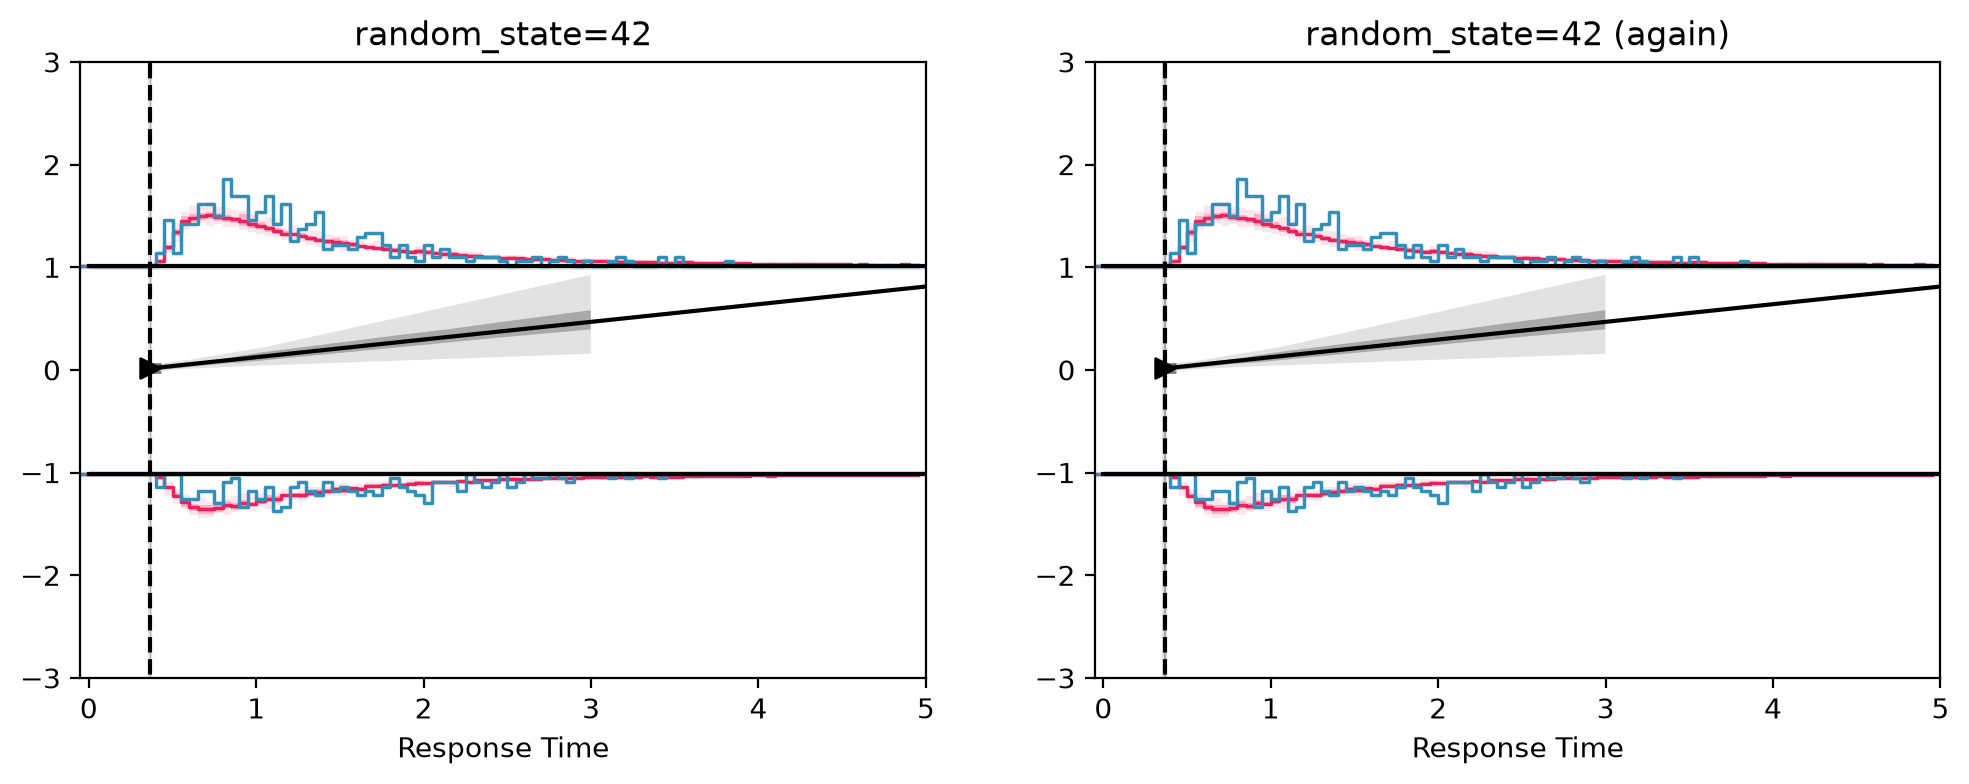

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax in axes:
    plot_model_cartoon(model, n_samples=10, random_state=42, ax=ax, legend=False)
axes[0].set_title("random_state=42")
axes[1].set_title("random_state=42 (again)");

## Conditioning the cartoon on one trial with `obs=`

For regression models every trial has its own parameters. By default the
drawn geometry summarizes each posterior draw by its **trial-mean** θ while
the RT histograms stay marginal over trials (they are a check against the
pooled observed data). Passing `obs=` instead conditions **every simulated
layer** — geometry, predicted histograms, trajectories — on that one trial's
parameters. Here trial 0 vs trial 40 of the Cavanagh data (different
`theta` values, hence different drift geometry); the observed histogram
remains pooled, and a warning says so:

obs=0 conditions the predicted histograms and geometry on one trial; the observed-data histogram remains pooled over trials.


No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


obs=40 conditions the predicted histograms and geometry on one trial; the observed-data histogram remains pooled over trials.


No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


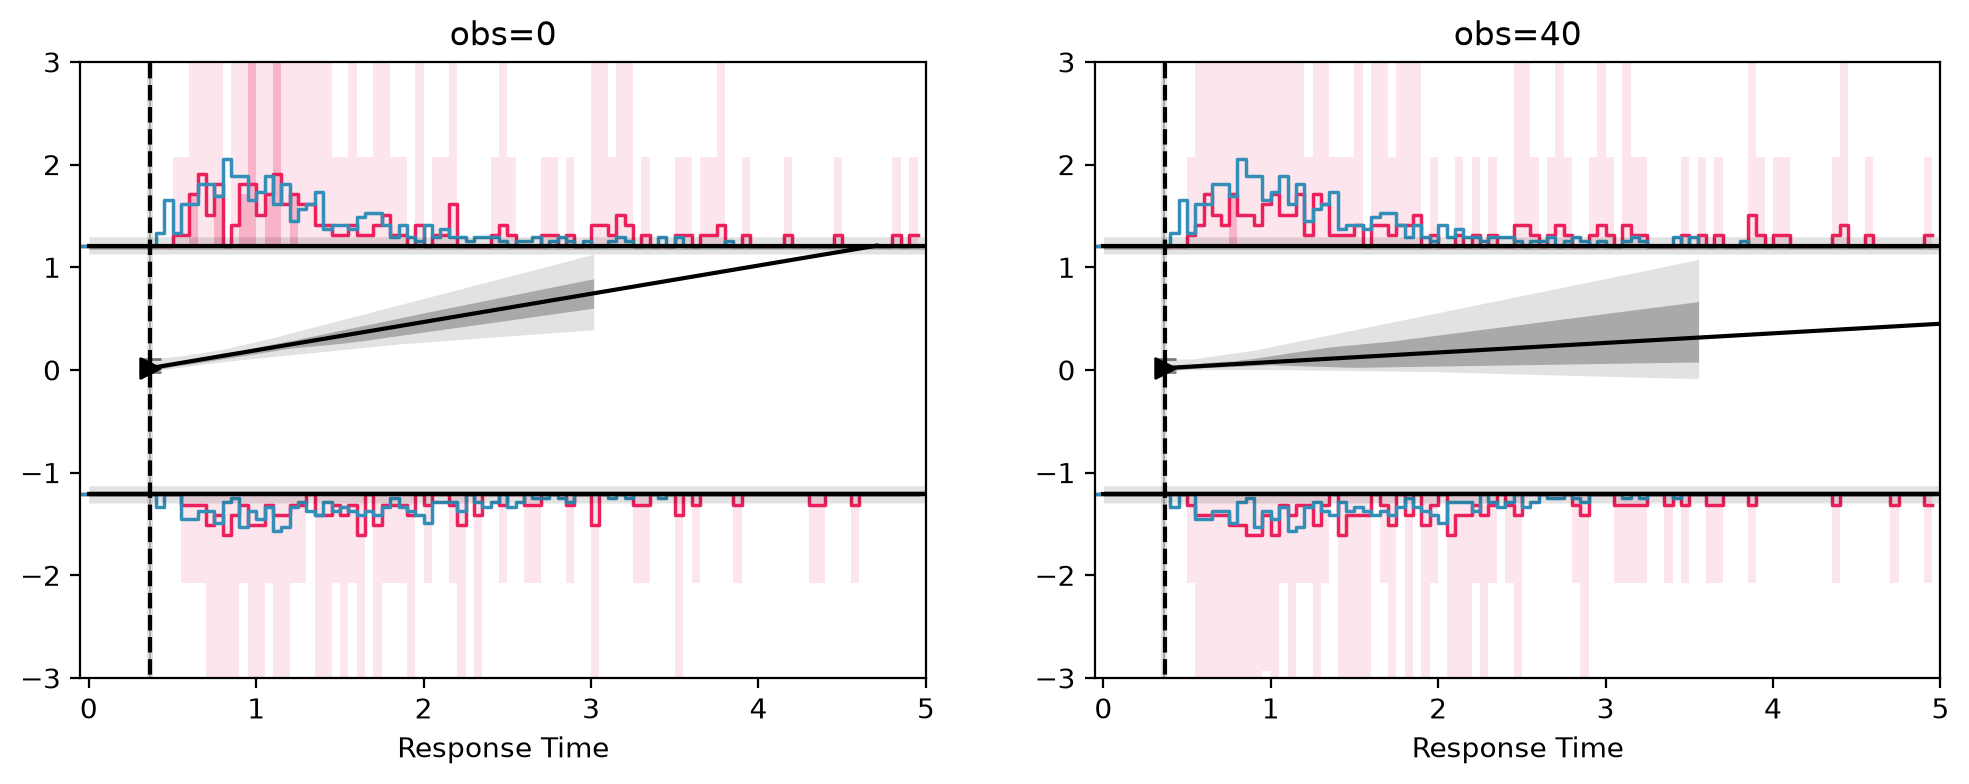

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, obs in zip(axes, (0, 40)):
    plot_model_cartoon(
        model, n_samples=10, obs=obs, random_state=7, ax=ax, legend=False
    )
    ax.set_title(f"obs={obs}")

## Legacy spellings still work

The old boolean pair maps onto the `uncertainty` vocabulary with a
`FutureWarning` — `plot_predictive_samples=True` becomes
`uncertainty="samples"`.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


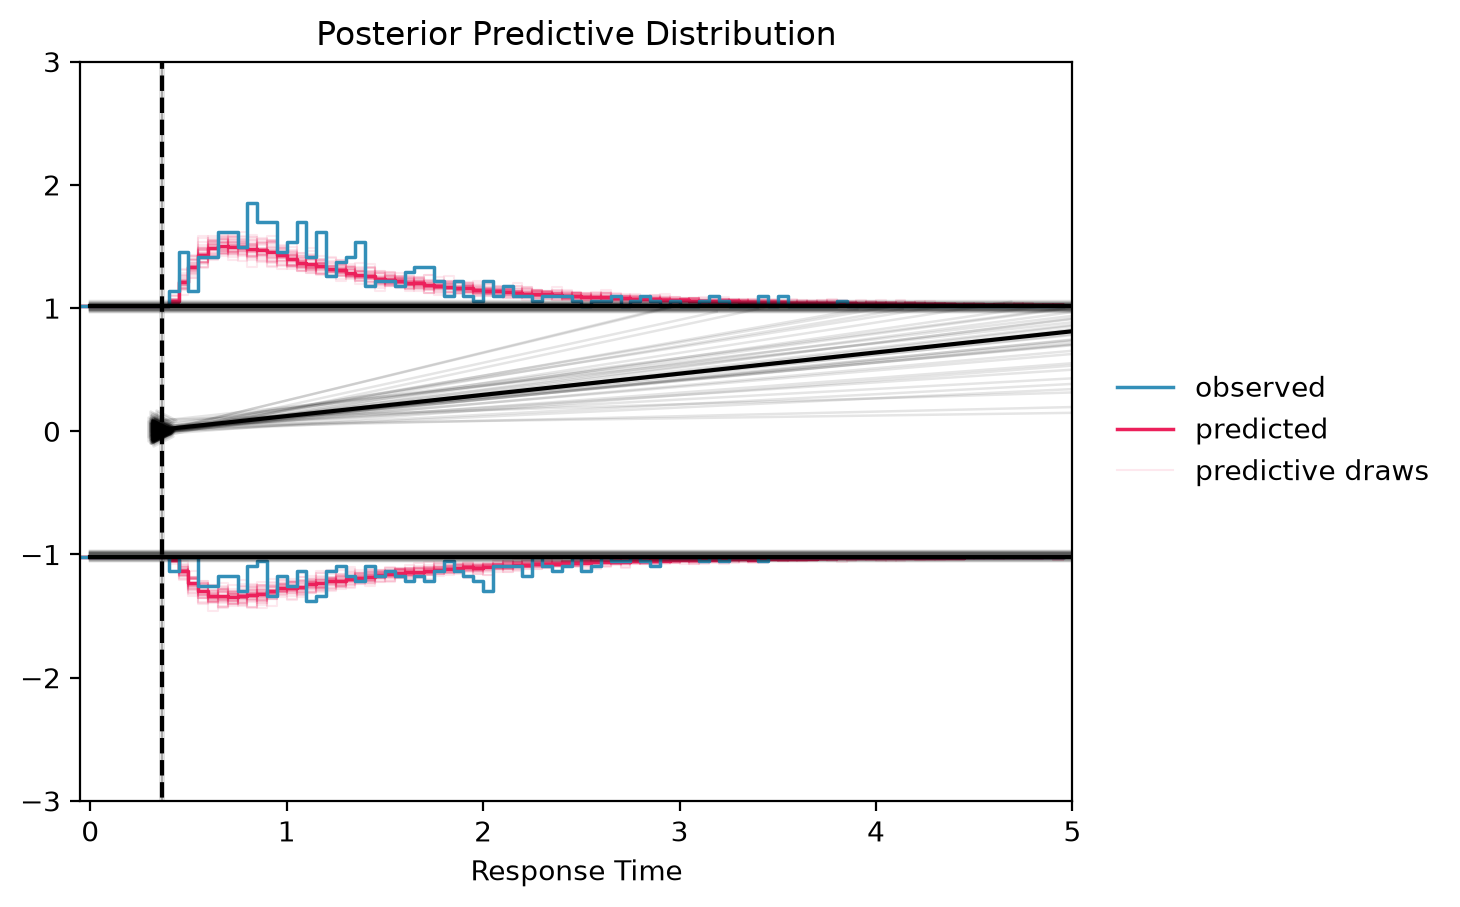

In [12]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    plot_model_cartoon(
        model, plot_predictive_mean=True, plot_predictive_samples=True, n_samples=20
    )

## A caveat for regression and hierarchical models

The geometry drawn for each posterior draw derives from that draw's
**trial-mean** parameter vector (or from one trial when `obs=` is given),
so boundary, drift, non-decision time, and starting point always describe
the same coherent θ. Keep in mind that the geometry is nonlinear in the
parameters: the curve drawn at the trial-mean θ is *not* the mean of the
per-trial curves and need not sit mid-band relative to the per-draw
uncertainty ribbons. The reduction is a display convention — the RT
histograms, which stay marginal over trials by default, remain the
statistically calibrated posterior-predictive layer.
